# Carga y filtro de datos

In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec 

DATA_PATH = Path("../data/ArchiveII.csv")
DISTANCE_PATH = Path("../data/ArchiveII_distances.h5")  
SUBSAMPLED_PATH = Path("../results/ArchiveII_subsampled_ids.csv") 

df_full = pd.read_csv(DATA_PATH, index_col="id")
mat = pd.read_hdf(DISTANCE_PATH, key="rnadist")
df_ids = pd.read_csv(SUBSAMPLED_PATH)

In [2]:

subsampled_ids = {}
for partition in df_ids["partition"].unique():
    subsampled_ids[partition] = df_ids.query(f"partition == '{partition}'")["id"].values

In [3]:

ids_sorts = {
    "Full": subsampled_ids["full"],
    "sortS400": subsampled_ids["sortS400"],
    "sortS200": subsampled_ids["sortS200"],
    "sortS100": subsampled_ids["sortS100"],
}

ids_cluss = {
    "Full": subsampled_ids["full"],
    "clusS400": subsampled_ids["clusS400"],
    "clusS200": subsampled_ids["clusS200"],
    "clusS100": subsampled_ids["clusS100"],
}
ids_rands = {
    "Full": subsampled_ids["full"],
    "randS400": subsampled_ids["randS400"],
    "randS200": subsampled_ids["randS200"],
    "randS100": subsampled_ids["randS100"],
}

families = sorted(df_full["fam"].unique())

idx_per_family = {
    fam: df_full.index[df_full["fam"] == fam].tolist()
    for fam in families
}

fams_to_visualize = ["5s", "tRNA", "tmRNA", "RNaseP", "srp"]
selected_fams = {
    fam: idx_per_family[fam]
    for fam in fams_to_visualize
}

dist_mat = mat.copy()
max_val = dist_mat.values.max().item() 

In [4]:
def sort_matrix(matrix): 
    avg = matrix.mean(axis=0)
    sorted_matrix_ids = avg.sort_values().index
    return matrix.loc[sorted_matrix_ids, sorted_matrix_ids] 

def sort_matrix_ids(matrix):  
    avg = matrix.mean(axis=0)
    sorted_matrix_ids = avg.sort_values().index
    return sorted_matrix_ids

# Analisis y plots

In [5]:
def plot_matrices_sort_ids(selected_fams, ids_subsample, dist_mat, max_val):
    n_rows = len(selected_fams)
    n_cols = len(ids_subsample)
    fig = plt.figure(figsize=(4. * n_cols + 1.2, 5 * n_rows))

    gs = gridspec.GridSpec(
        n_rows,
        n_cols + 1,  # +1 para la barra de color
        width_ratios=[1] * n_cols + [0.05],
        # width_ratios=[1, 1, 1, 1, 0.06],
        wspace=0.1,
        hspace=0.02,
    )

    for row_idx, (fam, fam_ids) in enumerate(selected_fams.items()):
        fam_mat = dist_mat.loc[fam_ids, fam_ids] / max_val 
        fam_ids = sort_matrix_ids(fam_mat) 
        
        for col_idx, (label, ids_subset) in enumerate(ids_subsample.items()): 
            ids_fam_subset = pd.Index(fam_ids).intersection(ids_subset).tolist() 
            sub_mat = fam_mat.loc[ids_fam_subset, ids_fam_subset] 

            if len(ids_fam_subset) == 0:
                print(f"[WARNING] {fam} - {label}: no ids found")
                continue

            ax = fig.add_subplot(gs[row_idx, col_idx])
            im = ax.imshow(sub_mat,  vmin=0, vmax=0.7, cmap="viridis", )

            if col_idx == 0: 
                ax.set_ylabel(fam)
                ax.set_title(f"n={len(ids_fam_subset)}", fontsize=10)
                
            if row_idx == 0:
                if col_idx == 0:
                    label = label + f" (n={len(ids_subset)})"
                else:
                    ax.set_title(label)
            ax.set_xticks([])
            ax.set_yticks([])

    # colorbar 
    cax = fig.add_subplot(gs[:, -1])
    fig.colorbar(im, cax=cax)
    plt.show()


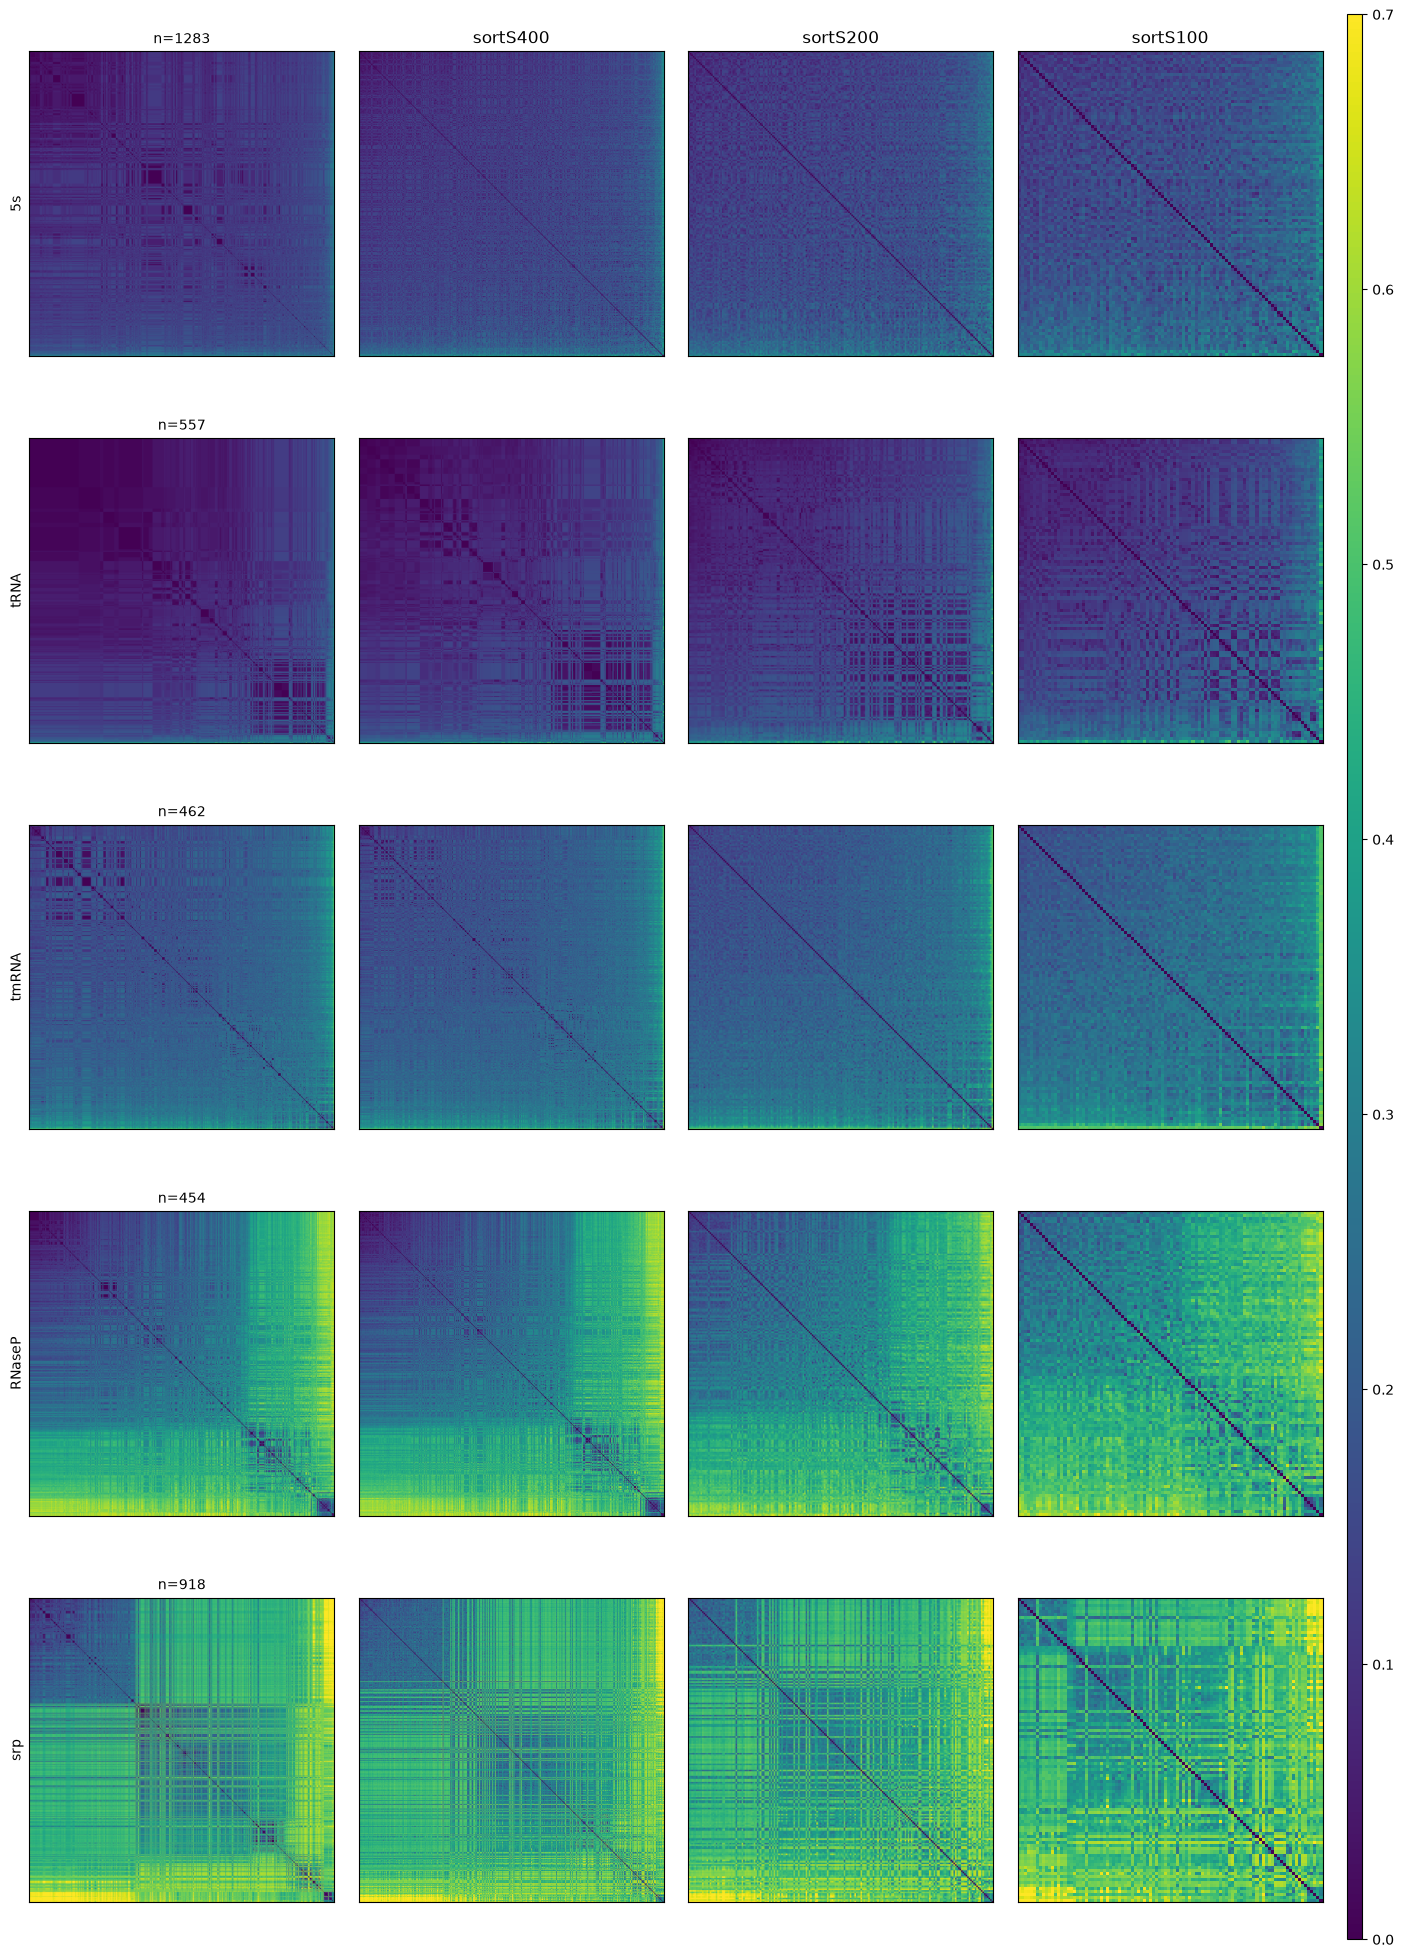

In [6]:
plot_matrices_sort_ids(selected_fams, ids_sorts, dist_mat, max_val)  

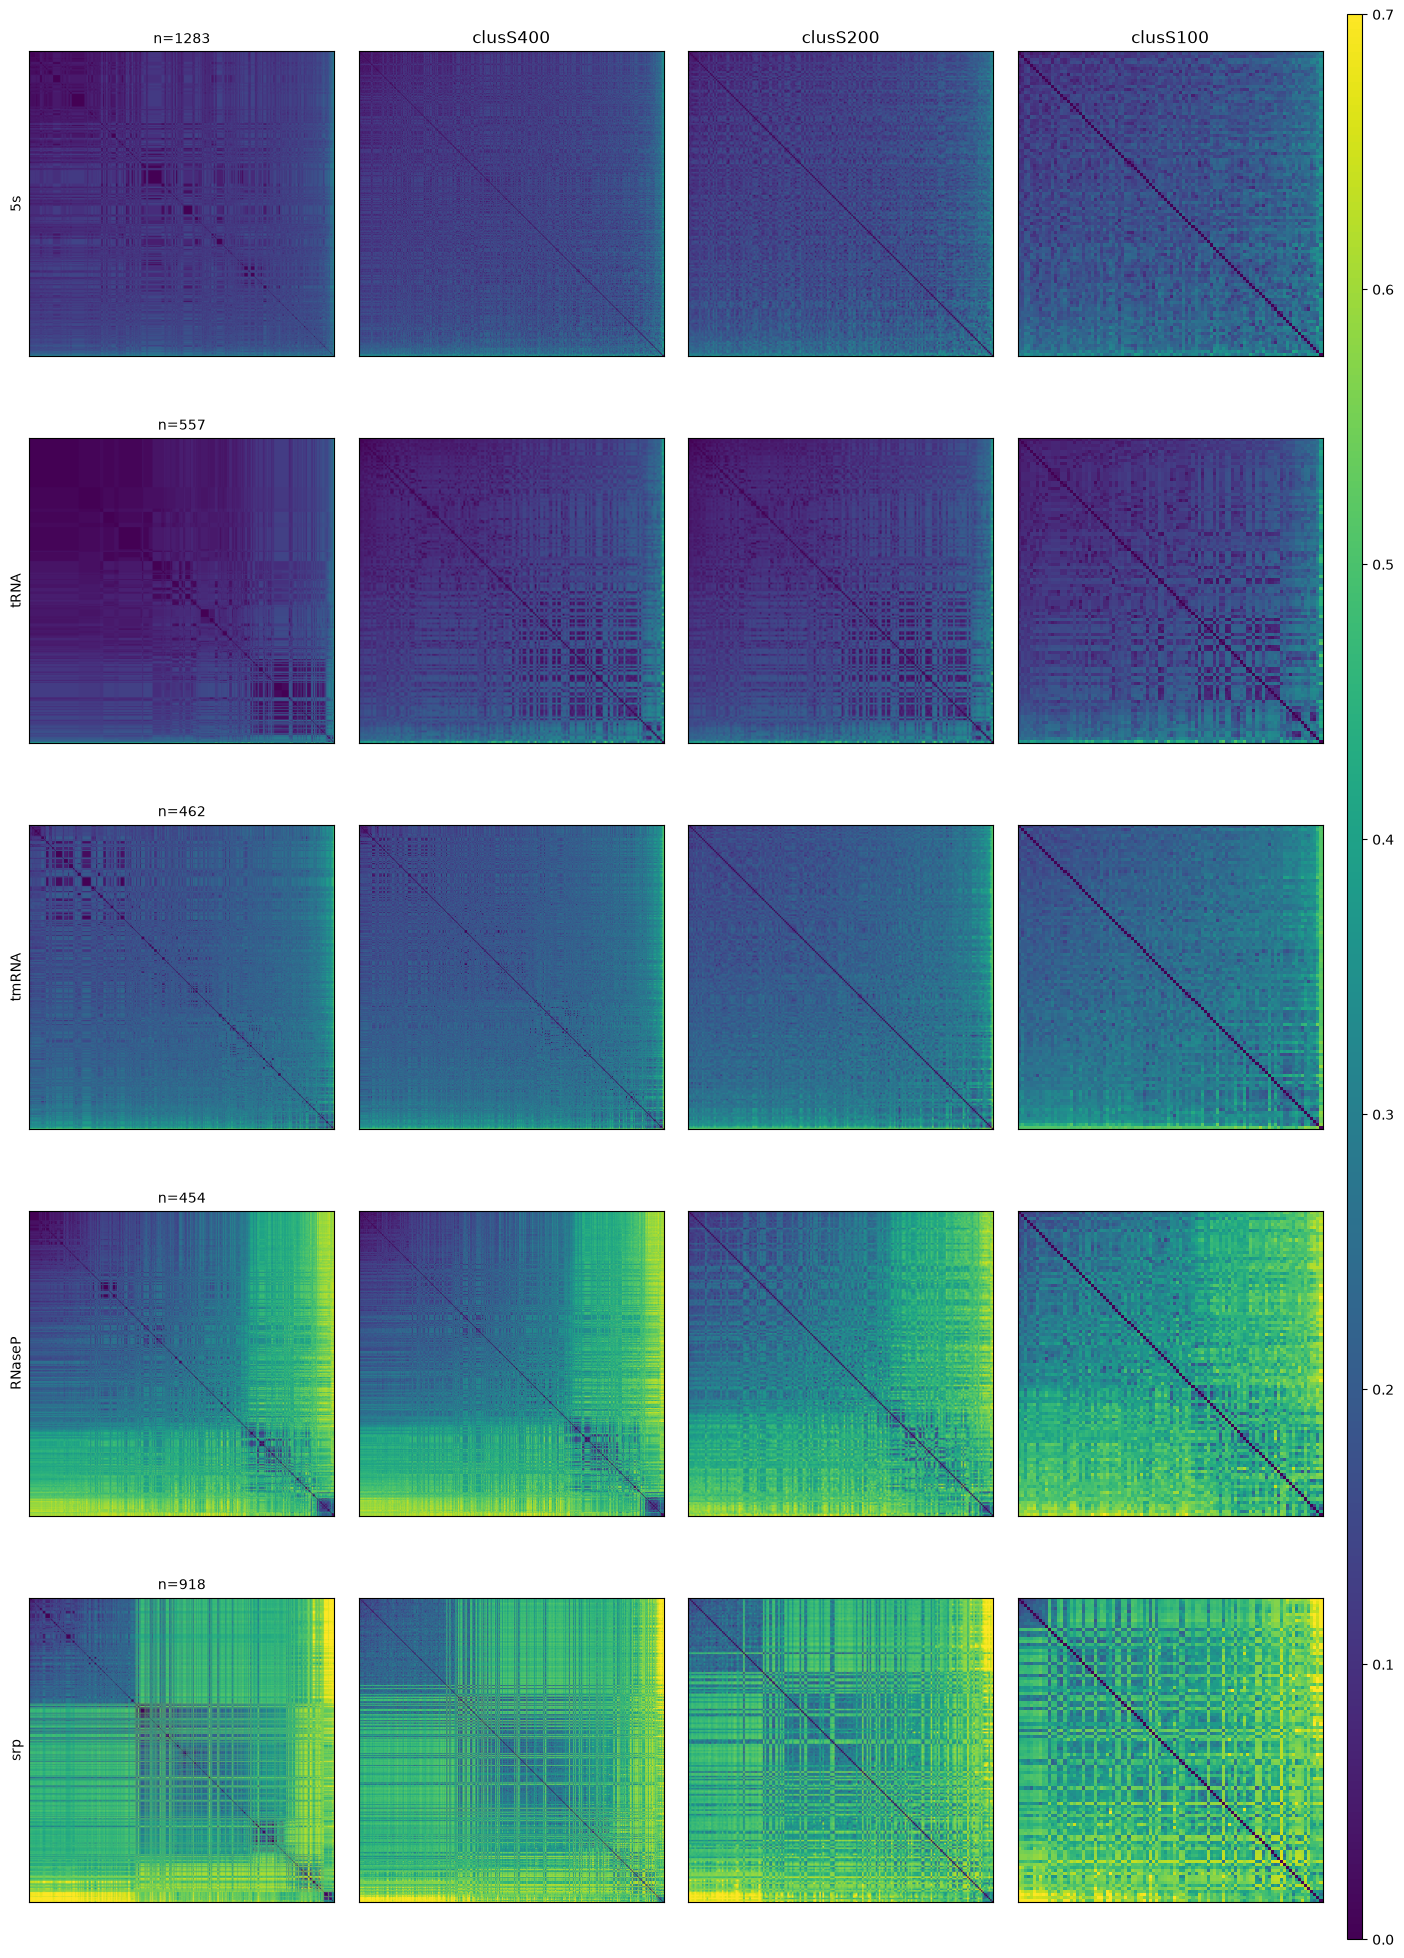

In [7]:
plot_matrices_sort_ids(selected_fams, ids_cluss, dist_mat, max_val)  

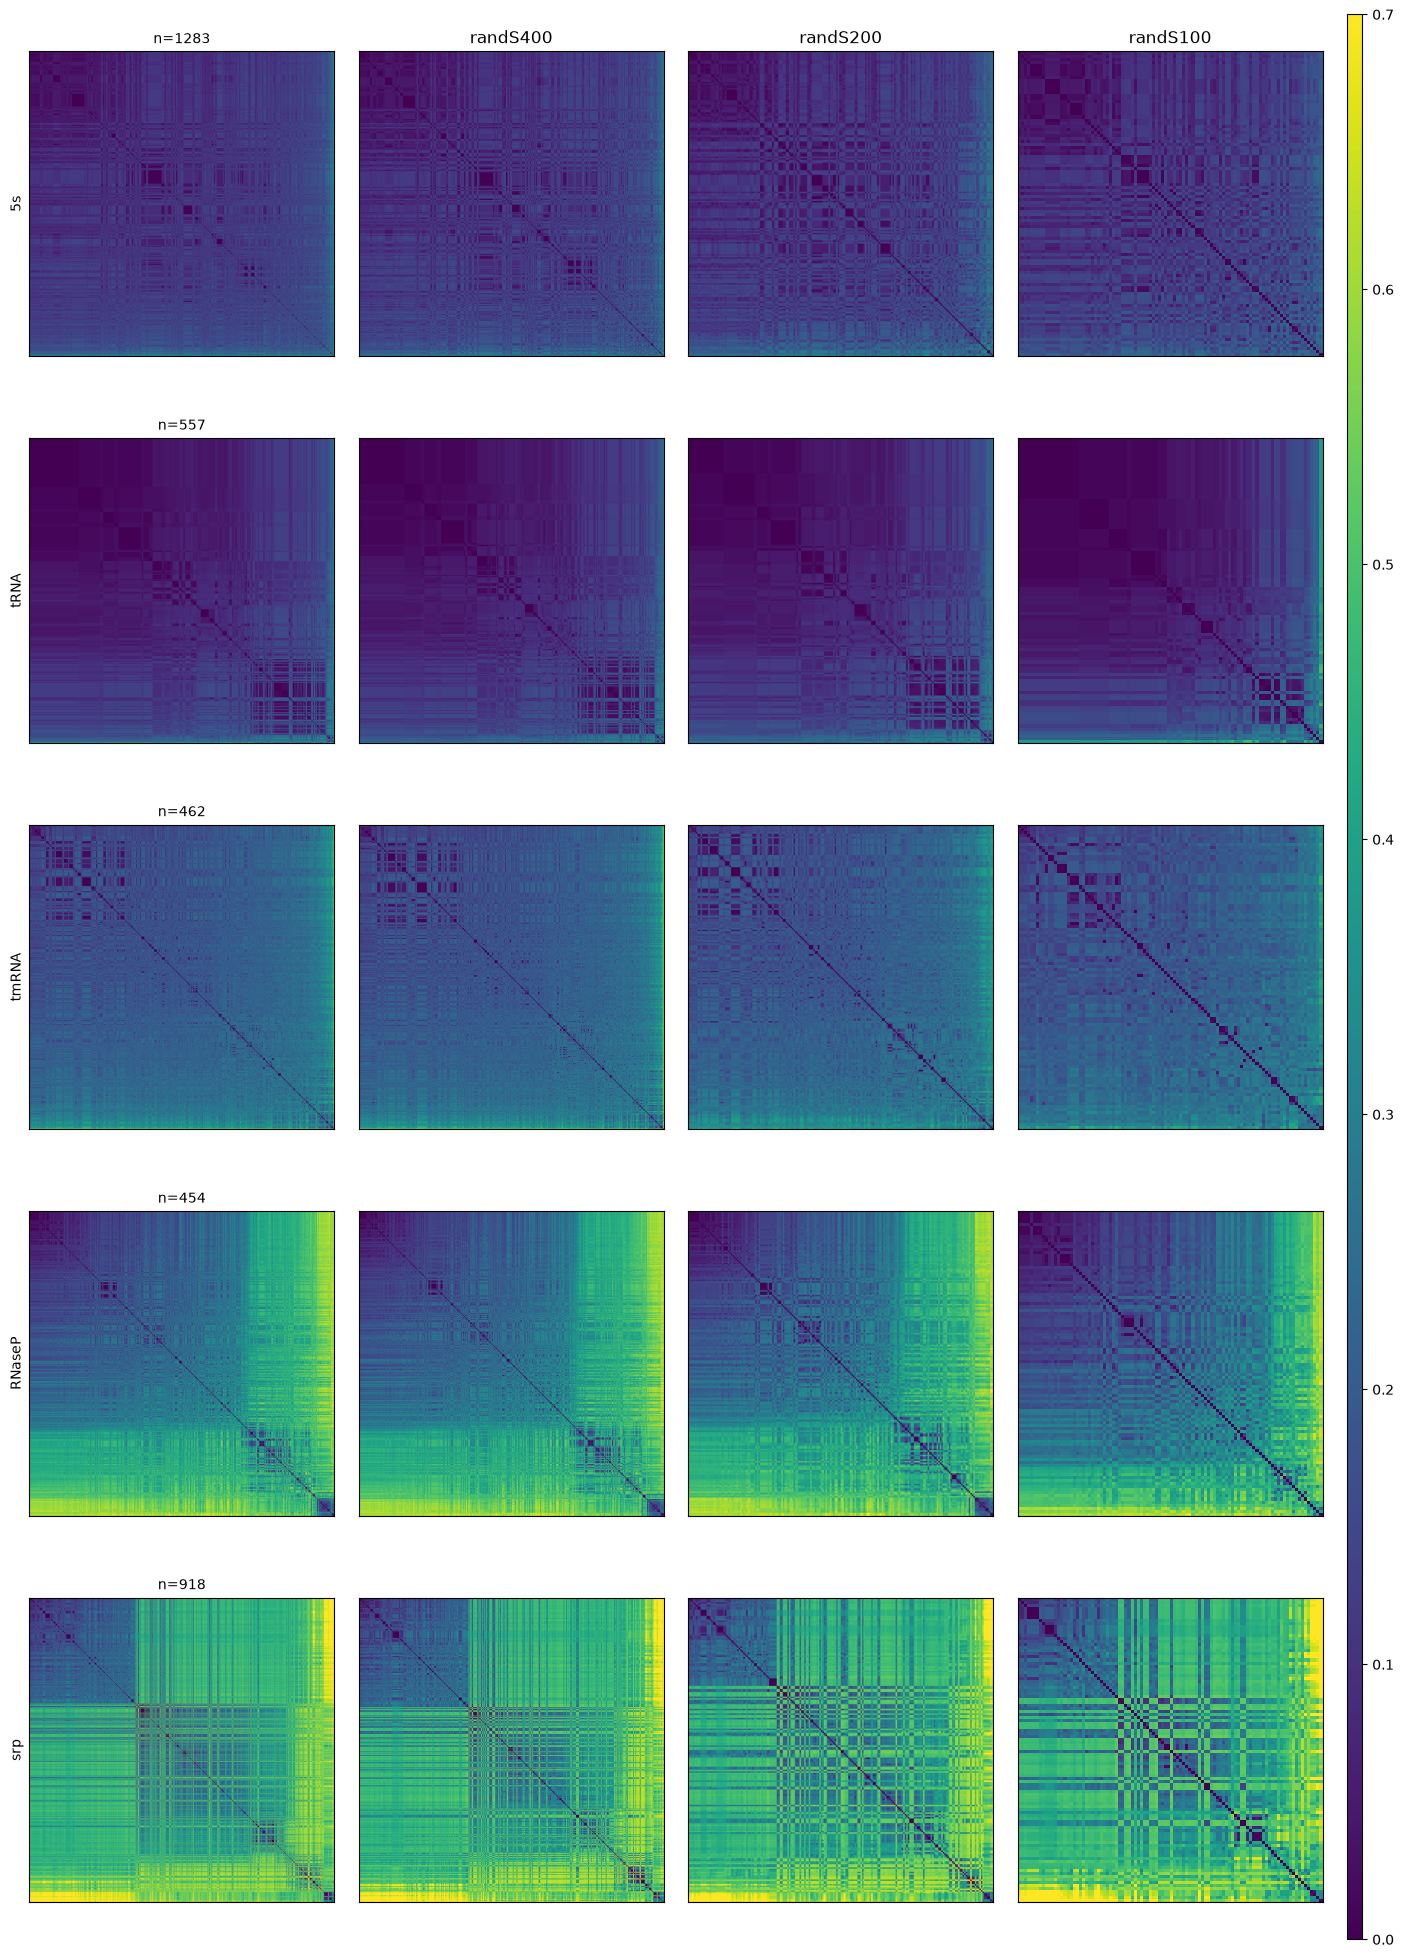

In [8]:
plot_matrices_sort_ids(selected_fams, ids_rands, dist_mat, max_val)  